## ¿Existe una asociación entre la tasa de divorcios y el nivel de criminalidad al aislar el efecto poblacional?

Se asume que las sociedades con mayor descomposición social (alta tasa de criminalidad) tienden a registrar mayores tasas de divorcio. Si la violencia destruye el hogar, deberíamos ver que a más violencia, más divorcios per cápita.

--- Iniciando Análisis de Tasas (Año 2018) ---
Datos de eventos cargados: 22 departamentos encontrados.
Departamentos con datos completos (Eventos + Población): 22

--- Calculando Tasas Normalizadas ---

Top 5 Departamentos por Tasa de VIF (2018):
     departamento  poblacion_censo  divorcios_total  vif_total    tasa_vif  \
4     El Progreso           176632            115.0       1023  579.170252   
15   Sacatepéquez           330469            153.0       1754  530.760828   
14     Retalhuleu           326828            153.0       1391  425.606129   
19  Suchitepéquez           554695            205.0       2050  369.572468   
0    Alta Verapaz          1215038            133.0       3892  320.319200   

    tasa_divorcios  
4        65.107115  
15       46.297837  
14       46.813615  
19       36.957247  
0        10.946160  

--- Resultados Estadísticos ---
Coeficiente de Correlación de Spearman (Rho): 0.4105
P-valor: 5.7741e-02
Conclusión estadística: La correlación es NO signif

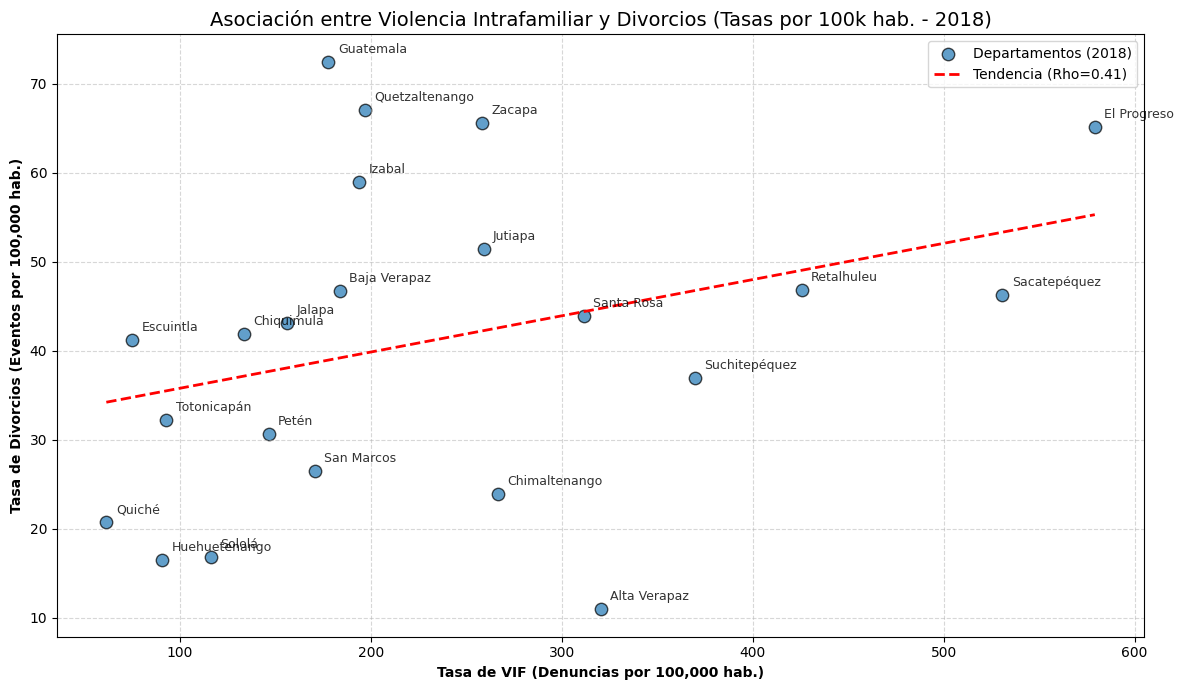

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
# ---------------------------------------------------------
# CONFIGURACIÓN DEL ENTORNO
# ---------------------------------------------------------
project_root = Path.cwd()
while not (project_root / 'data_pipeline.py').exists():
    if project_root.parent == project_root:
        raise FileNotFoundError("No se encontró data_pipeline.py")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
import data_pipeline as dp
# ---------------------------------------------------------
# 1. CARGA DE DATOS (EVENTOS Y POBLACIÓN)
# ---------------------------------------------------------
print("--- Iniciando Análisis de Tasas (Año 2018) ---")
try:
    # A) Cargar Panel de Eventos (Divorcios y VIF)
    df_panel = dp.build_panel(force_rebuild=False, only_common_years=False)
    
    # Filtrar SOLO el año 2018
    df_2018 = df_panel[df_panel['anio'] == 2018].copy()
    
    if df_2018.empty:
        raise ValueError("No se encontraron datos para el año 2018 en el panel.")
    
    print(f"Datos de eventos cargados: {len(df_2018)} departamentos encontrados.")
    # B) Cargar Población del Censo (Denominador)
    pob_path = project_root / 'Datos/Poblacion/poblacion_total.csv'
    if not pob_path.exists():
        raise FileNotFoundError(f"Archivo de población no encontrado en: {pob_path}")
    
    # Leer CSV limpio
    df_pob = pd.read_csv(pob_path)
    
    # Asegurar nombres de columnas clave
    # El archivo limpio tiene: Código, Departamento, Población total censada
    df_pob.rename(columns={
        'Departamento': 'departamento',
        'Población total censada': 'poblacion_censo',
        'Código': 'codigo_depto'
    }, inplace=True)
    # Convertir código a numérico para filtrar solo deptos válidos (1-22)
    # Esto elimina filas vacías o pies de página si quedaran
    df_pob['codigo_depto'] = pd.to_numeric(df_pob['codigo_depto'], errors='coerce')
    df_pob = df_pob.dropna(subset=['codigo_depto'])
    df_pob = df_pob[(df_pob['codigo_depto'] >= 1) & (df_pob['codigo_depto'] <= 22)]
    # Asegurar que población sea entero
    df_pob['poblacion_censo'] = df_pob['poblacion_censo'].astype(int)
    
    # Estandarizar nombres de departamentos
    df_pob['departamento'] = df_pob['departamento'].apply(dp._standardize_department)
    
    # Unir datos (Inner join para asegurar que tenemos ambos datos)
    df_final = pd.merge(df_2018, df_pob[['departamento', 'poblacion_censo']], on='departamento', how='inner')
    
    print(f"Departamentos con datos completos (Eventos + Población): {len(df_final)}")
except Exception as e:
    print(f"Error crítico en la carga de datos: {e}")
    raise
# ---------------------------------------------------------
# 2. CÁLCULO DE TASAS (POR 100k HABITANTES)
# ---------------------------------------------------------
print("\n--- Calculando Tasas Normalizadas ---")
# Tasa de Divorcios = (Divorcios / Poblacion) * 100,000
df_final['tasa_divorcios'] = (df_final['divorcios_total'] / df_final['poblacion_censo']) * 100000
# Tasa de VIF (Criminalidad) = (VIF Total / Poblacion) * 100,000
df_final['tasa_vif'] = (df_final['vif_total'] / df_final['poblacion_censo']) * 100000
# Limpieza final
df_analisis = df_final.dropna(subset=['tasa_divorcios', 'tasa_vif']).copy()
# Mostrar tabla resumen (Top 5 tasas más altas de VIF)
print("\nTop 5 Departamentos por Tasa de VIF (2018):")
display_cols = ['departamento', 'poblacion_censo', 'divorcios_total', 'vif_total', 'tasa_vif', 'tasa_divorcios']
print(df_analisis[display_cols].sort_values('tasa_vif', ascending=False).head(5))
# ---------------------------------------------------------
# 3. ANÁLISIS ESTADÍSTICO (CORRELACIÓN DE SPEARMAN)
# ---------------------------------------------------------
print("\n--- Resultados Estadísticos ---")
coef, p_value = spearmanr(df_analisis['tasa_vif'], df_analisis['tasa_divorcios'])
print(f"Coeficiente de Correlación de Spearman (Rho): {coef:.4f}")
print(f"P-valor: {p_value:.4e}")
sig_text = "significativa (p < 0.05)" if p_value < 0.05 else "NO significativa (p >= 0.05)"
print(f"Conclusión estadística: La correlación es {sig_text}.")
# ---------------------------------------------------------
# 4. VISUALIZACIÓN (SCATTERPLOT)
# ---------------------------------------------------------
print("\n--- Generando Gráfico de Dispersión ---")
plt.figure(figsize=(12, 7))  # Un poco más grande para mejor visibilidad
# Puntos principales
plt.scatter(df_analisis['tasa_vif'], df_analisis['tasa_divorcios'], 
            c='#1f77b4', alpha=0.7, s=80, edgecolors='k', label='Departamentos (2018)')
# Etiquetas inteligentes para departamentos (evitando superposiciones simples)
# Etiquetamos todos para identificar claramente quién es quién
for i, row in df_analisis.iterrows():
    plt.text(row['tasa_vif'] + 5, row['tasa_divorcios'] + 1, row['departamento'], fontsize=9, alpha=0.8)
# Línea de tendencia (Regresión simple para visualizar)
z = np.polyfit(df_analisis['tasa_vif'], df_analisis['tasa_divorcios'], 1)
p = np.poly1d(z)
x_range = np.linspace(df_analisis['tasa_vif'].min(), df_analisis['tasa_vif'].max(), 100)
plt.plot(x_range, p(x_range), "r--", linewidth=2, label=f'Tendencia (Rho={coef:.2f})')
plt.title('Asociación entre Violencia Intrafamiliar y Divorcios (Tasas por 100k hab. - 2018)', fontsize=14)
plt.xlabel('Tasa de VIF (Denuncias por 100,000 hab.)', fontweight='bold')
plt.ylabel('Tasa de Divorcios (Eventos por 100,000 hab.)', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()